In [1]:
#Import the necessary libraries for hyperparameter tuning
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

In [3]:
# ===============================
# 0) Setup
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# For reproducibility
RNG = 42


df = pd.read_csv(r"C:\Users\abdul\Downloads\Cleaned_df2.csv")  # Load your dataset
# Display the first few rows of the dataset
df.head()

,age,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,survived,gender_code,hist_code,smoking_code,cancer_stage_code,treatment_type_code,days_between
0,64,29.4,199,0,0,1,0,0,1,1,1.0,1,1,523
1,50,41.2,280,1,1,0,0,1,2,1,1.0,3,2,424
2,65,44.0,268,1,1,0,0,0,2,1,3.0,3,3,370
3,51,43.0,241,1,1,0,0,0,2,0,1.0,1,1,443
4,37,19.7,178,0,0,0,0,0,1,0,1.0,1,3,406


In [6]:
# Quick sanity check on columns you expect (edit if needed)
print("Columns:", df.columns.tolist())
print(df.head())

Columns: ['age', 'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'survived', 'gender_code', 'hist_code', 'smoking_code', 'cancer_stage_code', 'treatment_type_code', 'days_between']
   age   bmi  cholesterol_level  hypertension  asthma  cirrhosis  \
0   64  29.4                199             0       0          1   
1   50  41.2                280             1       1          0   
2   65  44.0                268             1       1          0   
3   51  43.0                241             1       1          0   
4   37  19.7                178             0       0          0   

   other_cancer  survived  gender_code  hist_code  smoking_code  \
0             0         0            1          1           1.0   
1             0         1            2          1           1.0   
2             0         0            2          1           3.0   
3             0         0            2          0           1.0   
4             0         0            1  


--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668102 entries, 0 to 668101
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  668102 non-null  int64  
 1   bmi                  668102 non-null  float64
 2   cholesterol_level    668102 non-null  int64  
 3   hypertension         668102 non-null  int64  
 4   asthma               668102 non-null  int64  
 5   cirrhosis            668102 non-null  int64  
 6   other_cancer         668102 non-null  int64  
 7   survived             668102 non-null  int64  
 8   gender_code          668102 non-null  int64  
 9   hist_code            668102 non-null  int64  
 10  smoking_code         668102 non-null  float64
 11  cancer_stage_code    668102 non-null  int64  
 12  treatment_type_code  668102 non-null  int64  
 13  days_between         668102 non-null  int64  
dtypes: float64(2), int64(12)
memory usage: 71.4 MB
None

-

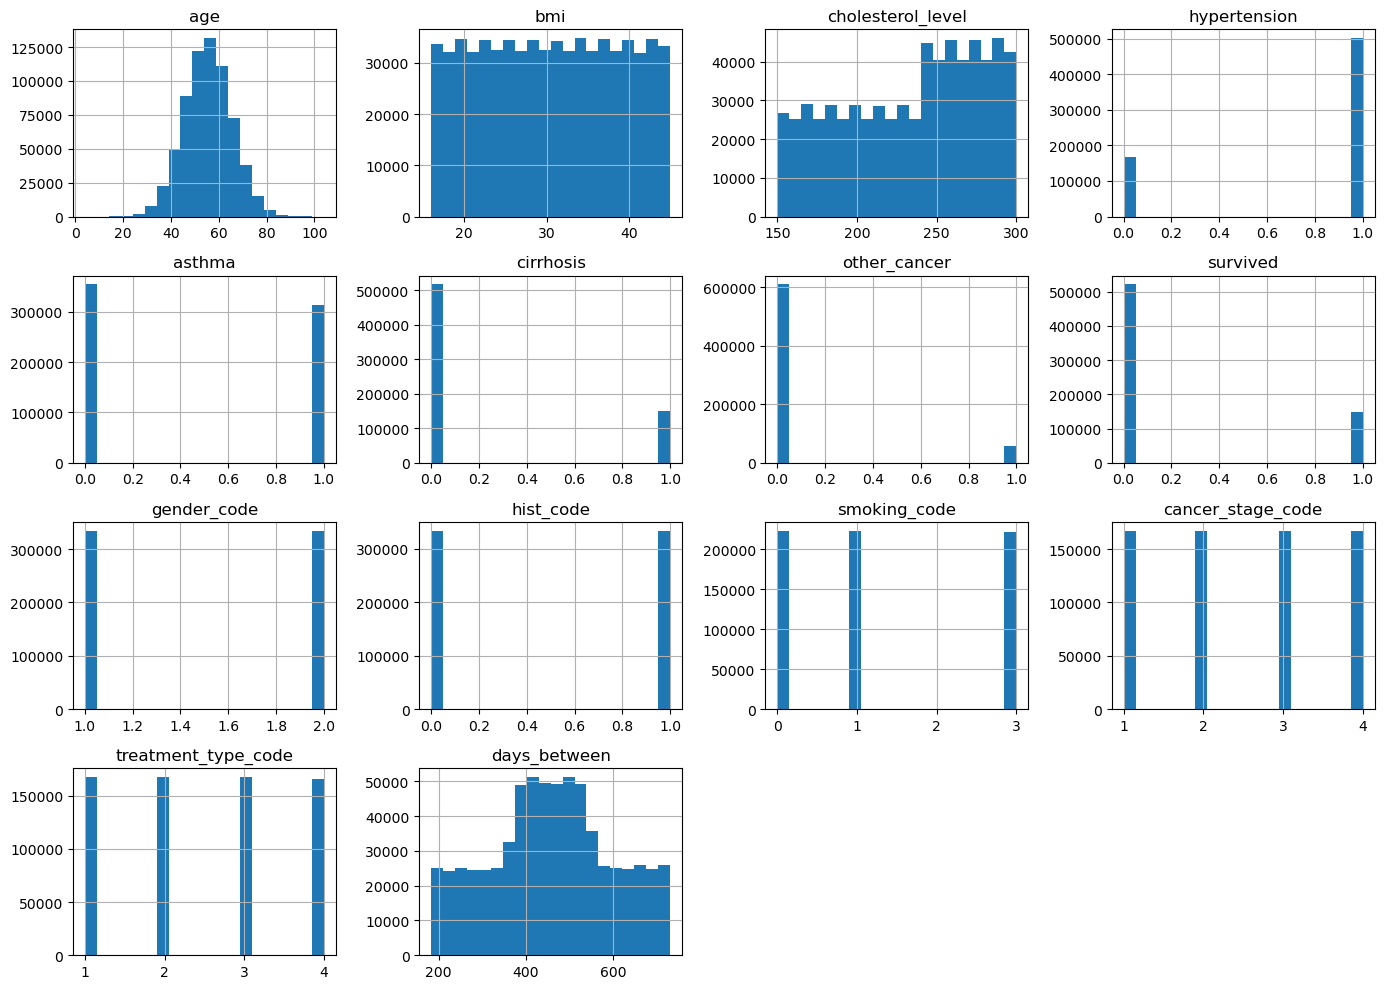

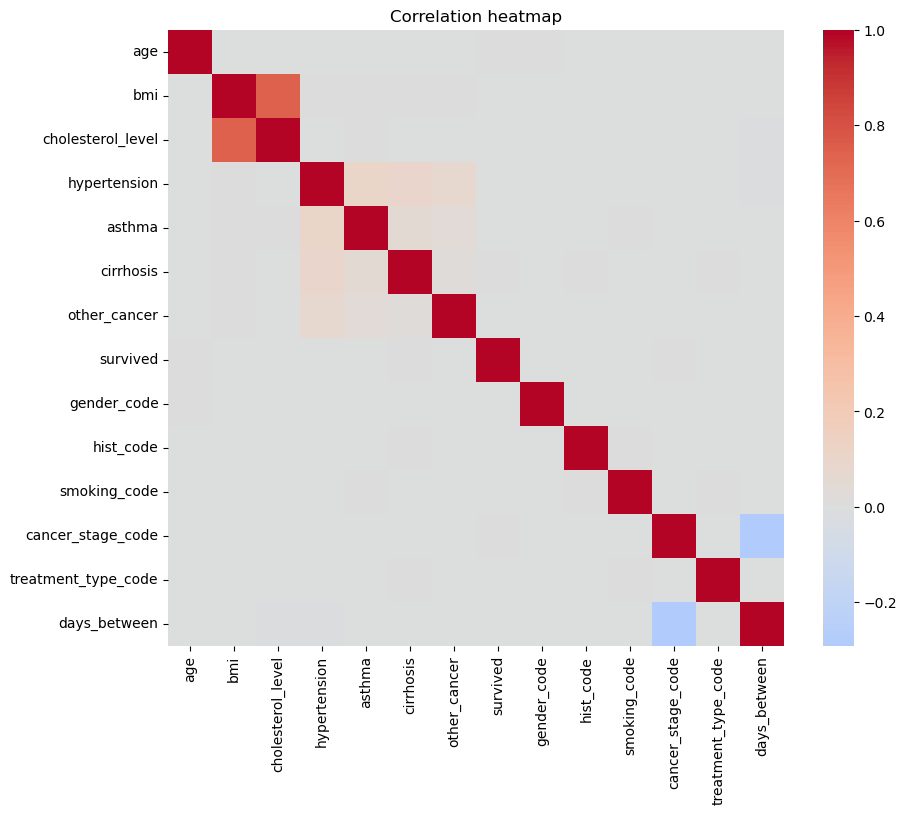

In [ ]:

# 2) EDA: structure, missingness, basic stats

print("\n--- Info ---")
print(df.info())

print("\n--- Missing values per column ---")
print(df.isna().sum().sort_values(ascending=False))

print("\n--- Descriptive statistics (numeric) ---")
print(df.describe().T)

# Class balance for target
target = "survived"
print("\n--- Target distribution ---")
print(df[target].value_counts(normalize=True).rename("proportion"))

# Histograms (quick look)
_ = df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation heatmap")
plt.show()

In [ ]:

# 3) Multicollinearity checks
#    - High pairwise correlation flags
#    - VIF (after simple imputation)

features = [c for c in df.columns if c != target]
X_raw = df[features].copy()

# Simple median impute for VIF calculation (avoid dropping rows)
X_imputed = X_raw.copy()
X_imputed = X_imputed.fillna(X_imputed.median(numeric_only=True))

# VIF requires an intercept
X_for_vif = sm.add_constant(X_imputed)
vif = pd.DataFrame({
    "feature": ["const"] + list(X_imputed.columns),
    "VIF": [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]
})
print("\n--- VIF ---")
print(vif.sort_values("VIF", ascending=False))

# (Optional) Flag highly correlated pairs
def high_corr_pairs(corr_mat, thresh=0.9):
    pairs = []
    cols = corr_mat.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if abs(corr_mat.iloc[i, j]) >= thresh:
                pairs.append((cols[i], cols[j], corr_mat.iloc[i, j]))
    return sorted(pairs, key=lambda x: -abs(x[2]))

hc = high_corr_pairs(corr.loc[features, features], thresh=0.5)
if hc:
    print("\nHighly correlated (|r| >= 0.5):")
    for a,b,r in hc:
        print(f"{a} ~ {b}: {r:.3f}")
else:
    print("\nNo pairs with |r| >= 0.5")



--- VIF ---
                feature         VIF
0                 const  102.742630
3     cholesterol_level    2.258841
2                   bmi    2.258795
13         days_between    1.092791
11    cancer_stage_code    1.092607
4          hypertension    1.025672
5                asthma    1.014863
6             cirrhosis    1.011806
7          other_cancer    1.006785
9             hist_code    1.000025
10         smoking_code    1.000022
12  treatment_type_code    1.000013
1                   age    1.000013
8           gender_code    1.000012

Highly correlated (|r| >= 0.5):
bmi ~ cholesterol_level: 0.747


In [44]:
# ===============================
# 4) Train / test split (stratified)
# ===============================
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RNG, stratify=y
)

# Standardize data for Logistic Regression
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Class imbalance handling: scale_pos_weight = (neg/pos)
pos_count = (y_train == 1).sum()
neg_count = (y_train == 0).sum()
scale_pos_weight = max(1.0, neg_count / max(1, pos_count))
print(f"\nscale_pos_weight suggestion (neg/pos): {scale_pos_weight:.3f}")


scale_pos_weight suggestion (neg/pos): 3.541


In [45]:
# Define features and target
X = df.drop("survived", axis=1)
y = df["survived"]

# Train-test split (stratified for class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# =====================================
# 2. Define XGBoost model
# =====================================
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",   # prevents warning
    use_label_encoder=False
)

# =====================================
# 3. Define hyperparameter grid
# =====================================
param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# =====================================
# 4. Grid Search with CV
# =====================================
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="roc_auc",    # better than accuracy for medical survival prediction
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_search_xgb.best_params_)
print("Best CV Score (ROC AUC):", grid_search_xgb.best_score_)

# =====================================
# 5. Evaluate Best Model
# =====================================
best_xgb = grid_search_xgb.best_estimator_

# Predictions
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("Test Accuracy:", accuracy_xgb)

# Confusion matrix
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", conf_matrix_xgb)

# ROC AUC (probability-based)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print("ROC AUC Score:", roc_auc_xgb)

# Classification report
target_names = ["Did Not Survive", "Survived"]
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, target_names=target_names))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV Score (ROC AUC): 0.5021216496280365
Test Accuracy: 0.779809510504862
Confusion Matrix:
 [[156298      0]
 [ 44133      0]]
ROC AUC Score: 0.5030825590582956

Classification Report:
                  precision    recall  f1-score   support

Did Not Survive       0.78      1.00      0.88    156298
       Survived       0.00      0.00      0.00     44133

       accuracy                           0.78    200431
      macro avg       0.39      0.50      0.44    200431
   weighted avg       0.61      0.78      0.68    200431



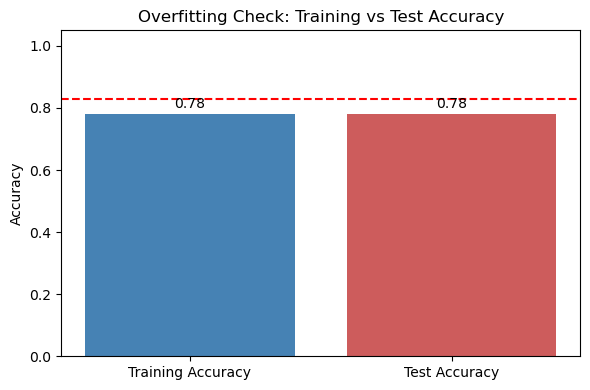

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Accuracy values
train_accuracy = accuracy_score(y_train, best_xgb.predict(X_train))
test_accuracy = accuracy_score(y_test, best_xgb.predict(X_test))

# Plot bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(['Training Accuracy', 'Test Accuracy'],
               [train_accuracy, test_accuracy],
               color=['steelblue', 'indianred'])

# Annotate bar values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01,
             f'{yval:.2f}', ha='center', va='bottom')

# Optional: Show overfitting threshold line *only if needed*
if train_accuracy > test_accuracy + 0.05:
    plt.axhline(test_accuracy + 0.05, color='red', linestyle='--', label='Overfitting Threshold')
    plt.legend()  # Now it has something to show

# Labels and styling
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.axhline(y=test_accuracy + 0.05, color='red', linestyle='--', label='Overfitting Threshold')
plt.title("Overfitting Check: Training vs Test Accuracy")
plt.tight_layout()
plt.show()

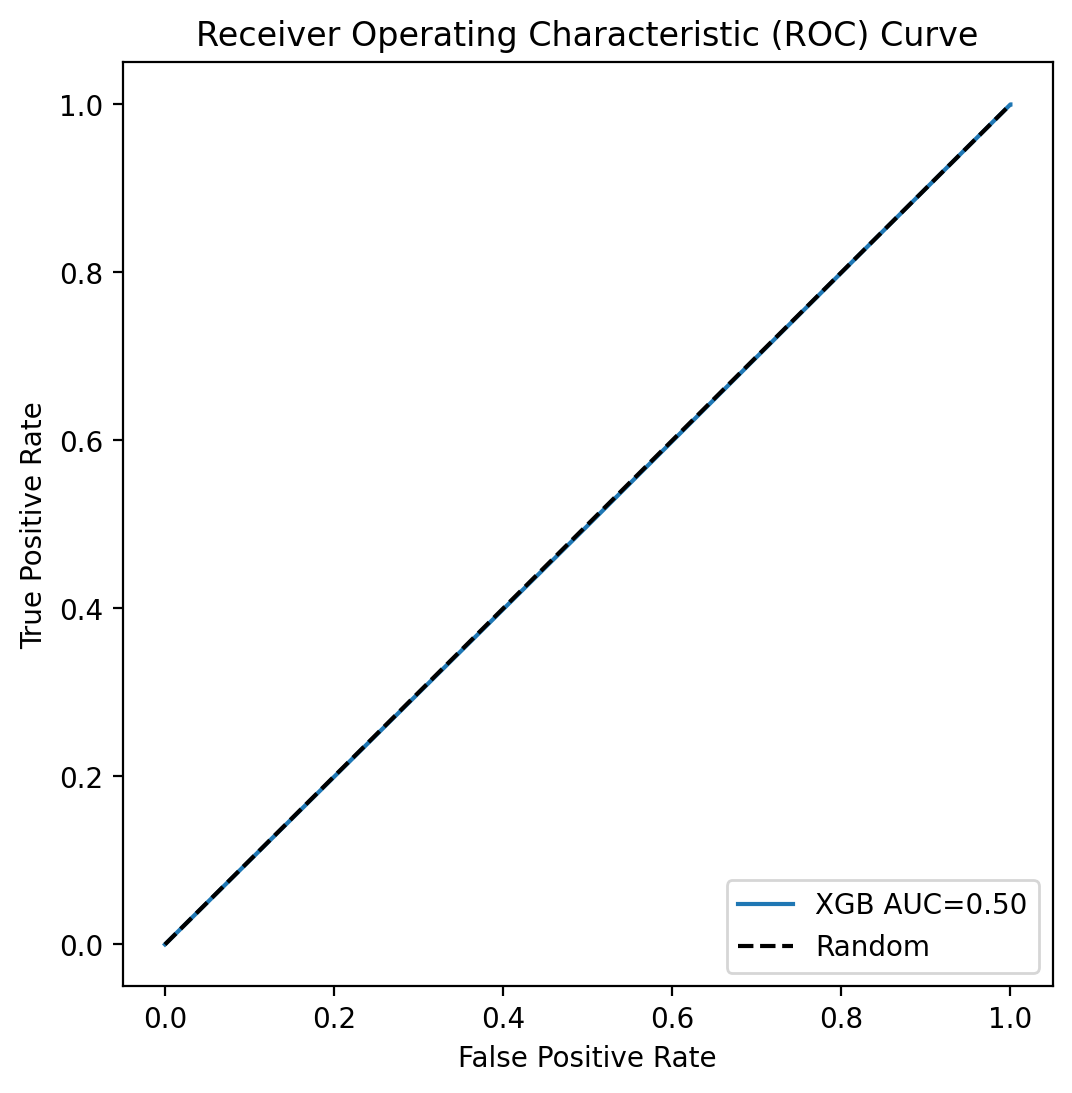

In [48]:
#AUC of ROC curve
from sklearn.metrics import classification_report, roc_auc_score, roc_curve 

# Define models with selected hyperparameters
models = [
       
    ('XGB', best_xgb)
]

# Initialize report and AUC score storage
report_data = []
auc_scores = {}

# Train models and evaluate on the test set
for name, model in models:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Generate classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    report['model'] = name
    report_data.append(report)
    
    # Compute AUC score
    auc_scores[name] = roc_auc_score(y_test, y_prob)

# Convert report data to DataFrame
report_df = pd.DataFrame(report_data).set_index('model')
report_df['auc_score'] = auc_scores.values()

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
for name, model in models:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} AUC={auc_scores[name]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', label='Random')  # Diagonal reference line
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Text(0.5, 0, 'XGBoost Feature Importance')

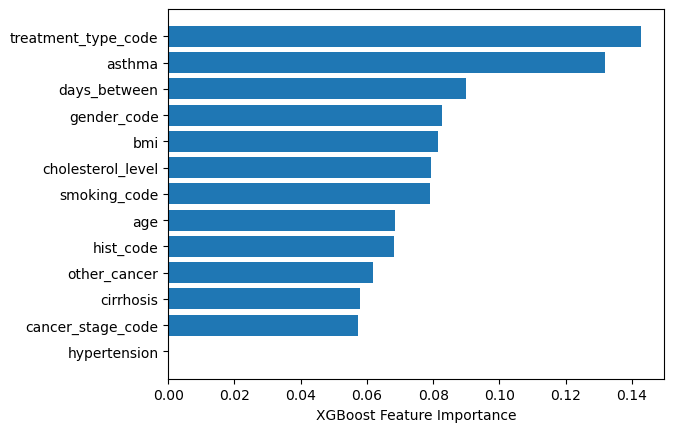

In [49]:
# XGboost Feature Importance
# Get feature importances
sort = best_xgb.feature_importances_.argsort() 
#making a plot 
plt.barh(X.columns[sort], best_xgb.feature_importances_[sort]) 
plt.xlabel("XGBoost Feature Importance")

##  Trying to ensure class balance to improve the accuracy

===== Baseline XGBoost =====
              precision    recall  f1-score   support

           0       0.78      1.00      0.88    156298
           1       0.00      0.00      0.00     44133

    accuracy                           0.78    200431
   macro avg       0.39      0.50      0.44    200431
weighted avg       0.61      0.78      0.68    200431

Confusion Matrix:
 [[156298      0]
 [ 44133      0]]
ROC AUC: 0.5030825590582956


===== XGBoost + scale_pos_weight =====
              precision    recall  f1-score   support

           0       0.78      0.42      0.54    156298
           1       0.22      0.59      0.32     44133

    accuracy                           0.45    200431
   macro avg       0.50      0.50      0.43    200431
weighted avg       0.66      0.45      0.49    200431

Confusion Matrix:
 [[65182 91116]
 [18206 25927]]
ROC AUC: 0.5025523270755088


===== SMOTE + XGBoost =====
              precision    recall  f1-score   support

           0       0.78      0.

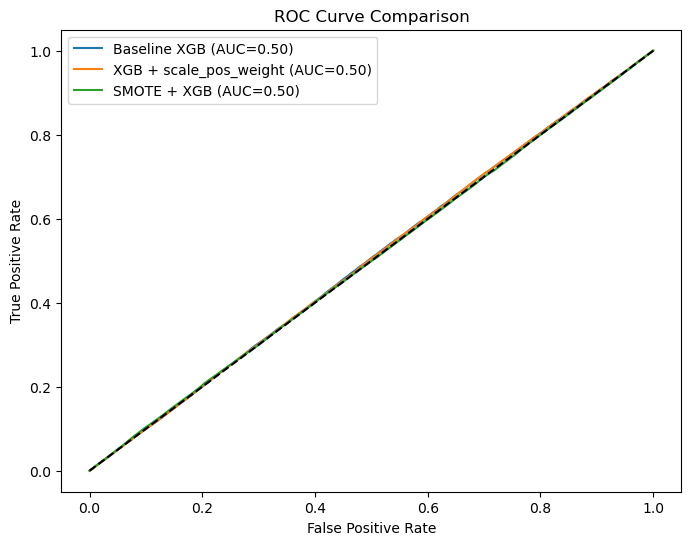

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# Split dataset
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# 1. Baseline XGBoost
baseline_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.01, random_state=42, use_label_encoder=False, eval_metric="logloss"
)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]

# 2. XGBoost with scale_pos_weight
neg, pos = np.bincount(y_train)
scale = neg / pos
weight_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.01,
    scale_pos_weight=scale, random_state=42, use_label_encoder=False, eval_metric="logloss"
)
weight_model.fit(X_train, y_train)
y_pred_weight = weight_model.predict(X_test)
y_proba_weight = weight_model.predict_proba(X_test)[:, 1]

# 3. SMOTE + XGBoost
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
smote_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.01, random_state=42, use_label_encoder=False, eval_metric="logloss"
)
smote_model.fit(X_res, y_res)
y_pred_smote = smote_model.predict(X_test)
y_proba_smote = smote_model.predict_proba(X_test)[:, 1]

# --- Evaluation Function ---
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"===== {name} =====")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_proba))
    print("\n")

# Evaluate
evaluate_model("Baseline XGBoost", y_test, y_pred_base, y_proba_base)
evaluate_model("XGBoost + scale_pos_weight", y_test, y_pred_weight, y_proba_weight)
evaluate_model("SMOTE + XGBoost", y_test, y_pred_smote, y_proba_smote)

# --- ROC Curve Comparison ---
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
fpr_weight, tpr_weight, _ = roc_curve(y_test, y_proba_weight)
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_proba_smote)

plt.figure(figsize=(8,6))
plt.plot(fpr_base, tpr_base, label="Baseline XGB (AUC=%.2f)" % roc_auc_score(y_test, y_proba_base))
plt.plot(fpr_weight, tpr_weight, label="XGB + scale_pos_weight (AUC=%.2f)" % roc_auc_score(y_test, y_proba_weight))
plt.plot(fpr_smote, tpr_smote, label="SMOTE + XGB (AUC=%.2f)" % roc_auc_score(y_test, y_proba_smote))
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


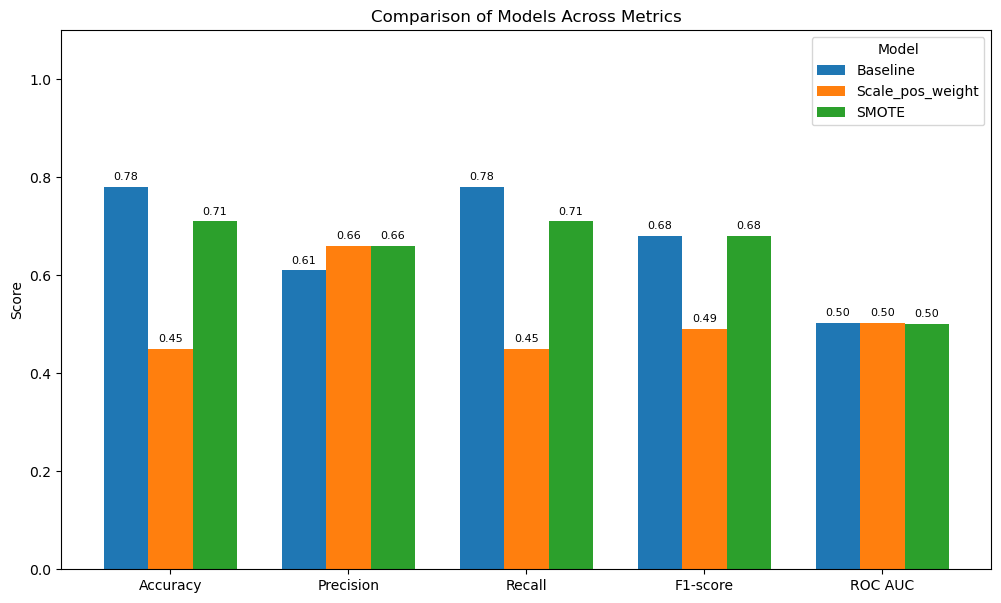

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics collected from your results
results = {
    "Baseline": {
        "Accuracy": 0.78,
        "Precision": 0.61,
        "Recall": 0.78,
        "F1-score": 0.68,
        "ROC AUC": 0.503
    },
    "Scale_pos_weight": {
        "Accuracy": 0.45,
        "Precision": 0.66,
        "Recall": 0.45,
        "F1-score": 0.49,
        "ROC AUC": 0.503
    },
    "SMOTE": {
        "Accuracy": 0.71,
        "Precision": 0.66,
        "Recall": 0.71,
        "F1-score": 0.68,
        "ROC AUC": 0.500
    }
}

# Prepare data
models = list(results.keys())
metrics = list(next(iter(results.values())).keys())
values = {model: [results[model][metric] for metric in metrics] for model in models}

# Plot grouped bar chart with metrics on x-axis
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12,7))
for i, model in enumerate(models):
    bars = ax.bar(x + i*width, values[model], width, label=model)
    # Add labels on each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel("Score")
ax.set_title("Comparison of Models Across Metrics")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend(title="Model")
plt.ylim(0, 1.1)
plt.show()


array([ 0,  1,  2, 12,  6,  3, 10, 11,  8,  7,  4,  5,  9], dtype=int64)

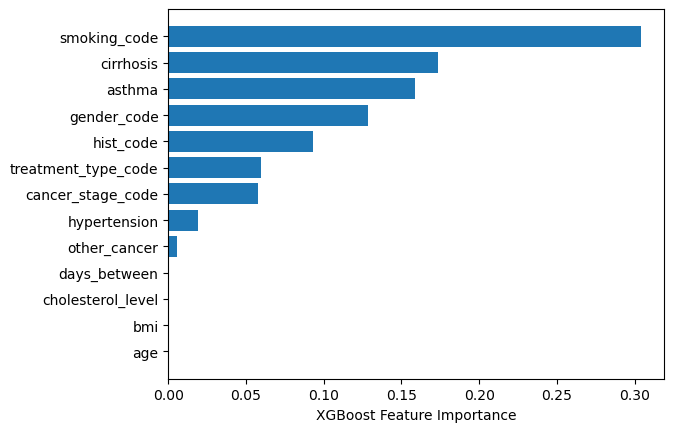

In [34]:
# XGboost Feature Importance
# Get feature importances
sort = smote_model.feature_importances_.argsort() 
#making a plot 
plt.barh(X.columns[sort], smote_model.feature_importances_[sort]) 
plt.xlabel("XGBoost Feature Importance")

sort

In [35]:
# Get feature importances and sort them
importances = smote_model.feature_importances_  
sorted_idx = importances.argsort()  # Better naming

# Create a DataFrame of feature names and importances
sm_df = pd.DataFrame({'Feature': X.columns[sorted_idx], 'Importance': importances[sorted_idx]})  

# Sort by importance in descending order
sm_imp = sm_df.sort_values("Importance", ascending=False)

# Display the DataFrame
sm_imp

,Feature,Importance
12,smoking_code,0.303806
11,cirrhosis,0.173780
10,asthma,0.158992
9,gender_code,0.128710
8,hist_code,0.093178
7,treatment_type_code,0.059447
6,cancer_stage_code,0.057890
5,hypertension,0.018837
4,other_cancer,0.005359
0,age,0.000000
